# Notebook 6: The Logarithmic Barrier Method

In the previous notebooks we explored KKT conditions and how to solve equality-constrained problems. Now we tackle the harder problem: **inequality constraints**.

The key idea is to convert inequality constraints into a penalty that forces the solution to stay in the interior of the feasible region, and then carefully shrink that penalty to zero.

**Prerequisites:** Notebooks 1-5 (unconstrained optimization, KKT conditions, Newton's method)

**Learning objectives:**
- Understand how log barriers encode inequality constraints
- Visualize the central path as a parametric family of interior solutions
- Implement a complete barrier method
- See how complementarity emerges naturally from barrier stationarity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import solve
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=True)
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Motivation: The Problem with Inequality Constraints

Consider a simple constrained problem:
$$\min_{x} f(x) \quad \text{s.t.} \quad x \geq x_l$$

The feasible set is $x \geq x_l$. If we apply unconstrained Newton's method, nothing prevents us from stepping outside the feasible region.

**Naive approach:** Project back to the boundary when we step out. Problem: the projected point may not be a KKT point, and projection can destroy quadratic convergence.

**Barrier approach:** Add a term $-\mu \log(x - x_l)$ to the objective. This term:
- Is $+\infty$ at $x = x_l$ (boundary) — prevents crossing
- Is finite for all $x > x_l$ (interior)
- Has gradient $-\mu/(x - x_l)$ pointing away from the boundary
- Vanishes as $\mu \to 0$ (so we're only minimizing $f$ asymptotically)

The key insight: **we never need to think about the constraint explicitly** — it's encoded in the barrier term.

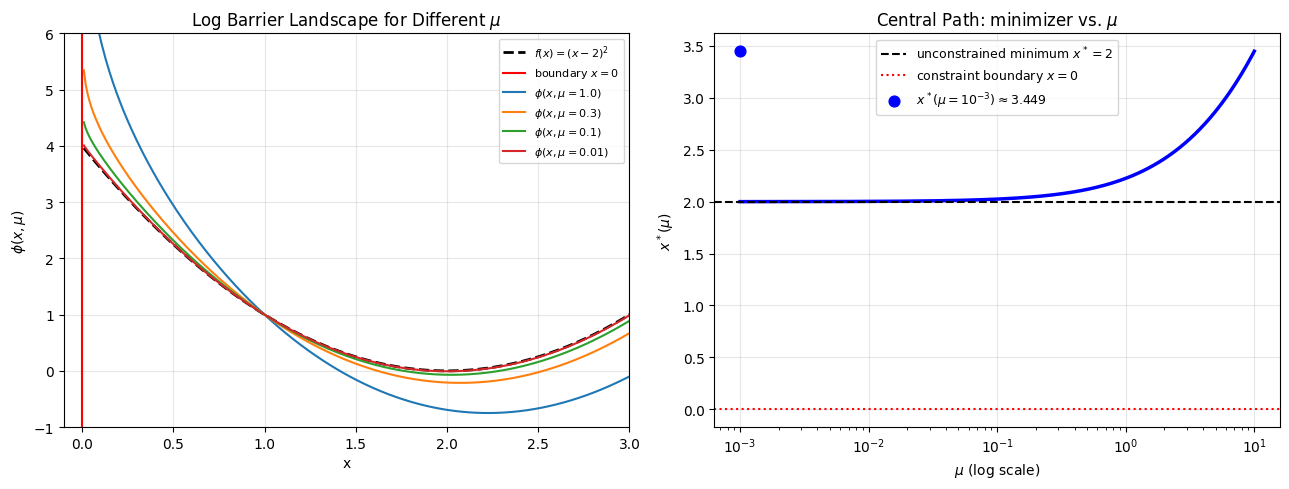

As mu -> 0, the barrier minimizer approaches the true constrained minimum x* = 2


In [2]:
# Visualize the log barrier for a single lower bound x >= 0
x = np.linspace(0.01, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: show how barrier landscape changes with mu
ax = axes[0]
f_obj = (x - 2)**2  # objective: min at x=2
ax.plot(x, f_obj, 'k--', lw=2, label='$f(x) = (x-2)^2$')
ax.axvline(0, color='red', lw=1.5, label='boundary $x=0$')

for mu in [1.0, 0.3, 0.1, 0.01]:
    barrier = f_obj - mu * np.log(x)  # x_l = 0
    ax.plot(x, barrier, label=f'$\\phi(x,\\mu={mu})$')

ax.set_xlim(-0.1, 3)
ax.set_ylim(-1, 6)
ax.set_xlabel('x')
ax.set_ylabel('$\\phi(x, \\mu)$')
ax.set_title('Log Barrier Landscape for Different $\\mu$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: show central path (minimizer as function of mu)
ax = axes[1]
# At minimum of phi: df/dx - mu/x = 0 => 2(x-2) - mu/x = 0 => 2x^2 - 4x - mu = 0
# x*(mu) = (4 + sqrt(16 + 8*mu)) / 4
mus = np.logspace(-3, 1, 200)
x_star = (4 + np.sqrt(16 + 8 * mus)) / 4

ax.semilogx(mus, x_star, 'b-', lw=2.5)
ax.axhline(2.0, color='k', ls='--', label='unconstrained minimum $x^*=2$')
ax.axhline(0.0, color='r', ls=':', label='constraint boundary $x=0$')
ax.scatter([1e-3], [x_star[-1]], color='blue', zorder=5, s=60, label=f'$x^*(\\mu=10^{{-3}}) \\approx {x_star[-1]:.3f}$')
ax.set_xlabel('$\\mu$ (log scale)')
ax.set_ylabel('$x^*(\\mu)$')
ax.set_title('Central Path: minimizer vs. $\\mu$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('barrier_intro.png', dpi=100, bbox_inches='tight')
plt.show()
print('As mu -> 0, the barrier minimizer approaches the true constrained minimum x* = 2')

## 2. Log Barrier for Variable Bounds

For bounds $x_l \leq x \leq x_u$ (componentwise), the **logarithmic barrier function** is:
$$\phi(x, \mu) = f(x) - \mu \sum_i \log(x_i - x_{l,i}) - \mu \sum_i \log(x_{u,i} - x_i)$$

The domain is $\{x : x_l < x < x_u\}$ (strictly interior).

**Gradient:**
$$\nabla_x \phi = \nabla f(x) - \mu \sum_i \frac{e_i}{x_i - x_{l,i}} + \mu \sum_i \frac{e_i}{x_{u,i} - x_i}$$

In vector form, defining $s_{l,i} = x_i - x_{l,i}$ (lower slack) and $s_{u,i} = x_{u,i} - x_i$ (upper slack):
$$\nabla_x \phi = \nabla f(x) - \mu S_l^{-1} e + \mu S_u^{-1} e$$

**Hessian:**
$$\nabla^2_x \phi = \nabla^2 f(x) + \mu \text{diag}(s_l^{-2}) + \mu \text{diag}(s_u^{-2}) = \nabla^2 f + \Sigma$$

where $\Sigma = \mu (S_l^{-2} + S_u^{-2})$ is the **barrier contribution** to the Hessian — always positive definite!

In [3]:
def barrier_objective(x, f_func, g_ineq_funcs, x_l, x_u, mu):
    """
    Compute the barrier objective phi(x, mu).

    phi(x, mu) = f(x) - mu * sum_i log(x_i - x_l_i) - mu * sum_i log(x_u_i - x_i)
                       - mu * sum_j log(-g_j(x))  [for inequality constraints g_j(x) <= 0]

    Parameters
    ----------
    x : array, shape (n,)
    f_func : callable, returns scalar
    g_ineq_funcs : list of callables, each returns scalar, g_j(x) <= 0
    x_l : array, shape (n,), lower bounds (-inf for unbounded)
    x_u : array, shape (n,), upper bounds (+inf for unbounded)
    mu : float, barrier parameter > 0

    Returns
    -------
    float : phi(x, mu), or +inf if x is infeasible
    """
    n = len(x)
    f_val = f_func(x)

    barrier = 0.0

    # Lower bounds
    for i in range(n):
        if np.isfinite(x_l[i]):
            slack = x[i] - x_l[i]
            if slack <= 0:
                return np.inf
            barrier -= mu * np.log(slack)

    # Upper bounds
    for i in range(n):
        if np.isfinite(x_u[i]):
            slack = x_u[i] - x[i]
            if slack <= 0:
                return np.inf
            barrier -= mu * np.log(slack)

    # Inequality constraints g_j(x) <= 0: add -mu * log(-g_j(x))
    # g_ineq_funcs is a list of (g_func, jac_func) tuples; we only need g_func here
    for g_func, _ in g_ineq_funcs:
        g_val = g_func(x)
        if g_val >= 0:  # constraint violated
            return np.inf
        barrier -= mu * np.log(-g_val)

    return f_val + barrier


def barrier_gradient(x, grad_f_func, jac_g_funcs, x_l, x_u, mu):
    """
    Compute gradient of phi(x, mu) with respect to x.

    grad phi = grad_f - mu * S_l^{-1} e + mu * S_u^{-1} e - mu * sum_j (grad g_j / (-g_j))
    """
    n = len(x)
    g = grad_f_func(x).copy()

    for i in range(n):
        if np.isfinite(x_l[i]):
            g[i] -= mu / (x[i] - x_l[i])
        if np.isfinite(x_u[i]):
            g[i] += mu / (x_u[i] - x[i])

    for (g_func, jac_func) in jac_g_funcs:
        g_val = g_func(x)
        jac_val = jac_func(x)
        g -= mu * jac_val / (-g_val)  # -mu * (-jac) / (-g) = -mu * jac / (-g)

    return g


def barrier_hessian(x, hess_f_func, jac_g_funcs, x_l, x_u, mu):
    """
    Compute Hessian of phi(x, mu).

    Hess phi = Hess_f + Sigma_bounds + Sigma_ineq
    where Sigma_bounds = mu * diag(s_l^{-2} + s_u^{-2})
    and   Sigma_ineq  = mu * sum_j (jac_j * jac_j^T / g_j^2)  [positive semidefinite]

    Note: second-order terms from constraints omitted here (Gauss-Newton approximation).
    For small residuals near optimum this is fine.
    """
    n = len(x)
    H = hess_f_func(x).copy()

    Sigma = np.zeros(n)
    for i in range(n):
        if np.isfinite(x_l[i]):
            Sigma[i] += mu / (x[i] - x_l[i])**2
        if np.isfinite(x_u[i]):
            Sigma[i] += mu / (x_u[i] - x[i])**2

    H += np.diag(Sigma)

    for (g_func, jac_func) in jac_g_funcs:
        g_val = g_func(x)
        jac_val = jac_func(x)
        H += mu * np.outer(jac_val, jac_val) / g_val**2

    return H


print('Barrier functions defined.')
print('Test: phi = f(x) - mu*log(x - x_l) - mu*log(x_u - x)')
x_test = np.array([0.5])
phi = barrier_objective(x_test,
                        lambda x: x[0]**2,
                        [],
                        np.array([0.0]),
                        np.array([2.0]),
                        0.1)
expected = 0.5**2 - 0.1*np.log(0.5 - 0.0) - 0.1*np.log(2.0 - 0.5)
print(f'  phi(0.5, mu=0.1) = {phi:.6f}  (expected {expected:.6f})')

Barrier functions defined.
Test: phi = f(x) - mu*log(x - x_l) - mu*log(x_u - x)
  phi(0.5, mu=0.1) = 0.278768  (expected 0.278768)


## 3. The Central Path

For each $\mu > 0$, there is a unique minimizer $x^*(\mu)$ of $\phi(x, \mu)$ (assuming $f$ is convex or at least that a local minimum exists in the interior). The collection of all these minimizers:
$$\mathcal{C} = \{x^*(\mu) : \mu > 0\}$$
is called the **central path**.

**Key property:** As $\mu \to 0^+$, $x^*(\mu)$ converges to the constrained optimum $x^*$.

**Intuition:** For large $\mu$, the barrier dominates and pulls the solution toward the analytic center of the feasible set. For small $\mu$, $f$ dominates and the solution approaches the constrained optimum. The central path provides a continuous, differentiable curve connecting the analytic center to the optimum.

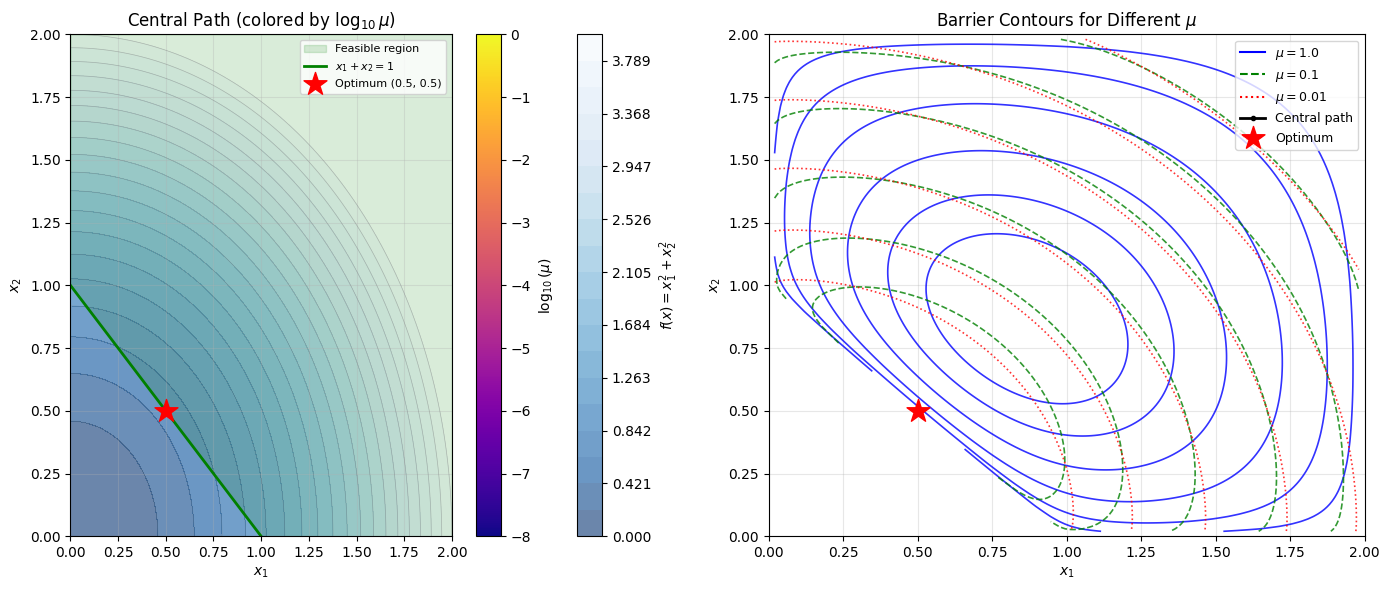


Final point: x = [0.5 0.5]
True optimum: x* = [0.5, 0.5]
Error: 2.27e-09


In [4]:
def central_path_demo():
    """
    Trace and visualize the central path for the problem:
      min  x1^2 + x2^2
      s.t. x1 + x2 >= 1
           0 <= x1 <= 2
           0 <= x2 <= 2

    Reformulate inequality x1+x2 >= 1 as -(x1+x2) + 1 <= 0 (g(x) <= 0 form)
    Barrier: phi = x1^2+x2^2 - mu*log(x1)+log(2-x1)+log(x2)+log(2-x2)+log(x1+x2-1))
    """
    # Problem functions
    f_func    = lambda x: x[0]**2 + x[1]**2
    grad_f    = lambda x: np.array([2*x[0], 2*x[1]])
    hess_f    = lambda x: 2*np.eye(2)

    # Inequality: -(x1+x2) + 1 <= 0, i.e., x1+x2 >= 1
    g_ineq    = lambda x: -(x[0] + x[1]) + 1.0  # must be < 0 in interior
    jac_g     = lambda x: np.array([-1.0, -1.0])

    x_l = np.array([0.0, 0.0])
    x_u = np.array([2.0, 2.0])

    g_ineq_funcs = [(g_ineq, jac_g)]

    # Trace central path
    mu_values = np.logspace(0, -8, 60)
    path = []

    x = np.array([0.8, 0.8])  # interior starting point

    for mu in mu_values:
        # Newton's method to minimize phi(x, mu)
        for _ in range(50):
            g = barrier_gradient(x, grad_f, g_ineq_funcs, x_l, x_u, mu)
            H = barrier_hessian(x, hess_f, g_ineq_funcs, x_l, x_u, mu)
            try:
                dx = np.linalg.solve(H, -g)
            except np.linalg.LinAlgError:
                break
            # Line search to stay feasible
            alpha = 1.0
            x_new = x + alpha * dx
            for _ in range(30):
                phi_new = barrier_objective(x_new, f_func, g_ineq_funcs, x_l, x_u, mu)
                if np.isfinite(phi_new):
                    break
                alpha *= 0.5
                x_new = x + alpha * dx
            else:
                break
            x = x_new
            if np.linalg.norm(g) < 1e-10:
                break
        path.append(x.copy())

    path = np.array(path)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left: central path on (x1, x2) plane ---
    ax = axes[0]
    x1g = np.linspace(0, 2, 300)
    x2g = np.linspace(0, 2, 300)
    X1, X2 = np.meshgrid(x1g, x2g)
    F = X1**2 + X2**2

    levels = np.linspace(0, 4, 20)
    cs = ax.contourf(X1, X2, F, levels=levels, cmap='Blues_r', alpha=0.6)
    ax.contour(X1, X2, F, levels=levels, colors='gray', linewidths=0.5, alpha=0.5)
    plt.colorbar(cs, ax=ax, label='$f(x) = x_1^2 + x_2^2$')

    # Feasible region shading: x1+x2 >= 1, 0<=x1<=2, 0<=x2<=2
    x1f = np.linspace(0, 2, 300)
    x2f_lower = np.maximum(1 - x1f, 0)
    ax.fill_between(x1f, x2f_lower, 2, alpha=0.15, color='green', label='Feasible region')
    ax.plot(x1f, 1 - x1f, 'g-', lw=2, label='$x_1 + x_2 = 1$')

    # Central path
    sc = ax.scatter(path[:, 0], path[:, 1], c=np.log10(mu_values[:len(path)]),
                    cmap='plasma', s=30, zorder=5)
    ax.plot(path[:, 0], path[:, 1], 'k-', lw=1, alpha=0.5)
    plt.colorbar(sc, ax=ax, label='$\\log_{10}(\\mu)$')

    # True optimum: x1=x2=0.5 (on x1+x2=1 constraint, equidistant)
    ax.scatter([0.5], [0.5], marker='*', s=300, color='red', zorder=10, label='Optimum (0.5, 0.5)')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Central Path (colored by $\\log_{10}\\mu$)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Right: barrier landscape for several mu ---
    ax = axes[1]
    x1g = np.linspace(0.02, 1.98, 200)
    x2g = np.linspace(0.02, 1.98, 200)
    X1, X2 = np.meshgrid(x1g, x2g)

    for mu_plot, color, ls in [(1.0, 'blue', '-'), (0.1, 'green', '--'), (0.01, 'red', ':')]:
        PHI = np.full_like(X1, np.nan)
        for i in range(len(x1g)):
            for j in range(len(x2g)):
                xij = np.array([X1[j, i], X2[j, i]])
                val = barrier_objective(xij, f_func, g_ineq_funcs, x_l, x_u, mu_plot)
                PHI[j, i] = val if np.isfinite(val) else np.nan

        # Find minimum of PHI for this mu
        finite_mask = np.isfinite(PHI)
        if finite_mask.any():
            min_idx = np.unravel_index(np.nanargmin(PHI), PHI.shape)
            ax.contour(X1, X2, PHI,
                       levels=np.nanpercentile(PHI[finite_mask], [10, 20, 35, 55, 75, 90]),
                       colors=[color], linestyles=[ls], linewidths=1.2,
                       alpha=0.8)
        ax.plot([], [], color=color, ls=ls, label=f'$\\mu = {mu_plot}$')

    ax.plot(path[:, 0], path[:, 1], 'k-o', lw=2, ms=3, label='Central path', zorder=5)
    ax.scatter([0.5], [0.5], marker='*', s=300, color='red', zorder=10, label='Optimum')
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Barrier Contours for Different $\\mu$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('central_path.png', dpi=100, bbox_inches='tight')
    plt.show()

    return path, mu_values

path, mu_values = central_path_demo()
print(f'\nFinal point: x = {path[-1]}')
print(f'True optimum: x* = [0.5, 0.5]')
print(f'Error: {np.linalg.norm(path[-1] - np.array([0.5, 0.5])):.2e}')

## 4. Barrier for General Inequality Constraints

For inequality constraints $g_j(x) \leq 0$, we add $-\mu \log(-g_j(x))$ to the barrier:
$$\phi(x, \mu) = f(x) - \mu \sum_i [\log(x_i - x_{l,i}) + \log(x_{u,i} - x_i)] - \mu \sum_j \log(-g_j(x))$$

At the stationarity condition $\nabla \phi = 0$:
$$\nabla f(x) - \mu S_l^{-1}e + \mu S_u^{-1}e + \sum_j \frac{\mu}{-g_j(x)} \nabla g_j(x) = 0$$

Defining **constraint multipliers** $\lambda_j = \mu / (-g_j(x)) > 0$, this becomes:
$$\nabla f(x) + \sum_j \lambda_j \nabla g_j(x) - z_l + z_u = 0$$

which is exactly the **KKT stationarity condition** with $\lambda_j > 0$, $g_j(x) < 0$ (strictly).

And the **barrier complementarity**: $\lambda_j \cdot (-g_j(x)) = \mu$ — a perturbation of the ideal $\lambda_j \cdot g_j(x) = 0$.

As $\mu \to 0$: either $\lambda_j \to 0$ (constraint inactive) or $g_j(x) \to 0$ (constraint active) — this recovers exact complementarity!

In [5]:
# Demonstrate how the barrier multiplier z = mu/(x - x_l) works

print('Barrier Complementarity: z * slack = mu')
print('='*50)
print()
print('Problem: min x^2, s.t. x >= 1 (i.e., x_l = 1)')
print('True optimum: x* = 1, z* = 2*1 = 2 (from KKT)')
print()

mu_list = [1.0, 0.1, 0.01, 0.001, 1e-4]
print(f'{'mu':>10}  {'x*(mu)':>10}  {'z*(mu)':>10}  {'z*slack':>10}  {'|z*slack - mu|':>15}')
print('-'*60)

for mu in mu_list:
    # Stationarity: 2x - mu/(x - 1) = 0  =>  2x(x-1) = mu  =>  2x^2 - 2x - mu = 0
    # x = (2 + sqrt(4 + 8*mu)) / 4
    x_opt = (2 + np.sqrt(4 + 8*mu)) / 4
    slack = x_opt - 1.0
    z_opt = mu / slack
    print(f'{mu:10.1e}  {x_opt:10.6f}  {z_opt:10.6f}  {z_opt*slack:10.6f}  {abs(z_opt*slack - mu):15.2e}')

print()
print('As mu -> 0: x* -> 1.0, z* -> 2.0 (=grad f at x*), z*slack -> 0 (complementarity!)')

Barrier Complementarity: z * slack = mu

Problem: min x^2, s.t. x >= 1 (i.e., x_l = 1)
True optimum: x* = 1, z* = 2*1 = 2 (from KKT)

        mu      x*(mu)      z*(mu)     z*slack   |z*slack - mu|
------------------------------------------------------------
   1.0e+00    1.366025    2.732051    1.000000         0.00e+00
   1.0e-01    1.047723    2.095445    0.100000         0.00e+00
   1.0e-02    1.004975    2.009950    0.010000         0.00e+00
   1.0e-03    1.000500    2.001000    0.001000         0.00e+00
   1.0e-04    1.000050    2.000100    0.000100         0.00e+00

As mu -> 0: x* -> 1.0, z* -> 2.0 (=grad f at x*), z*slack -> 0 (complementarity!)


## 5. The Barrier Method Algorithm

A complete barrier method drives $\mu$ to zero through a decreasing sequence, solving a Newton subproblem at each $\mu$.

```
Algorithm: Barrier Method
Input:  f, constraints, x0 (interior point), mu0, mu_min, sigma < 1
Output: x* (approximate constrained optimum)

x = x0
mu = mu0
while mu > mu_min:
    # Minimize phi(x, mu) using Newton's method
    while ||grad phi(x, mu)|| > tol_inner:
        H = hessian_phi(x, mu)
        g = gradient_phi(x, mu)
        dx = solve(H, -g)
        alpha = backtracking_line_search(x, dx, phi, mu)
        x = x + alpha * dx
    mu = sigma * mu   # reduce barrier parameter
return x
```

**Key difference from primal-dual IPM (next notebook):** Here we solve a *separate* unconstrained problem for each $\mu$. In primal-dual IPM, we update $x$ and the multipliers $z, \lambda$ *simultaneously*, taking just one or a few Newton steps per $\mu$ before reducing it. This is much more efficient.

In [6]:
def barrier_method(f_func, grad_f_func, hess_f_func, g_ineq_funcs,
                   x_l, x_u, x0, mu0=1.0, mu_min=1e-8,
                   sigma=0.1, tol_inner=1e-8, max_inner=100, verbose=True):
    """
    Full barrier method: decreasing sequence of mu, Newton at each mu.

    Returns
    -------
    x : final solution
    history : list of (mu, x, phi, grad_norm) for each outer iteration
    """
    x = x0.copy()
    mu = mu0
    history = []

    if verbose:
        print(f'{'Outer':>6}  {'mu':>10}  {'f(x)':>12}  {'||grad phi||':>14}')
        print('-'*48)

    outer = 0
    while mu > mu_min:
        # Inner Newton loop to minimize phi(x, mu)
        for inner in range(max_inner):
            g = barrier_gradient(x, grad_f_func, g_ineq_funcs, x_l, x_u, mu)
            H = barrier_hessian(x, hess_f_func, g_ineq_funcs, x_l, x_u, mu)

            if np.linalg.norm(g) < tol_inner:
                break

            try:
                dx = np.linalg.solve(H, -g)
            except np.linalg.LinAlgError:
                break

            # Backtracking line search: stay feasible
            alpha = 1.0
            phi_cur = barrier_objective(x, f_func, g_ineq_funcs, x_l, x_u, mu)
            c_armijo = 1e-4 * np.dot(g, dx)

            for _ in range(50):
                x_new = x + alpha * dx
                phi_new = barrier_objective(x_new, f_func, g_ineq_funcs, x_l, x_u, mu)
                if np.isfinite(phi_new) and phi_new <= phi_cur + alpha * c_armijo:
                    break
                alpha *= 0.5
            else:
                break  # line search failed

            x = x + alpha * dx

        phi_val = barrier_objective(x, f_func, g_ineq_funcs, x_l, x_u, mu)
        g_val   = barrier_gradient(x, grad_f_func, g_ineq_funcs, x_l, x_u, mu)
        gnorm   = np.linalg.norm(g_val)
        history.append((mu, x.copy(), phi_val, gnorm))

        if verbose:
            print(f'{outer:6d}  {mu:10.2e}  {f_func(x):12.6f}  {gnorm:14.2e}')

        mu = sigma * mu
        outer += 1

    return x, history


# Run barrier method on example problem
print('Barrier Method: min x1^2 + x2^2  s.t.  x1+x2 >= 1, 0 <= x1,x2 <= 2')
print('='*65)

f_func   = lambda x: x[0]**2 + x[1]**2
grad_f   = lambda x: np.array([2*x[0], 2*x[1]])
hess_f   = lambda x: 2*np.eye(2)
g_ineq   = lambda x: -(x[0] + x[1]) + 1.0
jac_g    = lambda x: np.array([-1.0, -1.0])
x_l = np.array([0.0, 0.0])
x_u = np.array([2.0, 2.0])
x0  = np.array([0.8, 0.8])  # strictly interior starting point

x_sol, hist = barrier_method(
    f_func, grad_f, hess_f,
    [(g_ineq, jac_g)],
    x_l, x_u, x0,
    mu0=1.0, mu_min=1e-8, sigma=0.1,
    verbose=True
)

print()
print(f'Solution:     x  = {x_sol}')
print(f'True optimum: x* = [0.5, 0.5]')
print(f'Objective: f(x) = {f_func(x_sol):.8f}  (true = 0.5)')
print(f'Constraint: x1+x2 = {x_sol[0]+x_sol[1]:.8f}  (should be >= 1, active at 1.0)')

Barrier Method: min x1^2 + x2^2  s.t.  x1+x2 >= 1, 0 <= x1,x2 <= 2
 Outer          mu          f(x)    ||grad phi||
------------------------------------------------
     0    1.00e+00      1.280000        4.03e+00
     1    1.00e-01      0.598613        2.89e+00
     2    1.00e-02      0.504287        4.71e+00
     3    1.00e-03      0.501000        2.83e+00
     4    1.00e-04      0.500098        2.86e+00
     5    1.00e-05      0.500010        2.86e+00
     6    1.00e-06      0.500001        2.87e+00
     7    1.00e-07      0.500000        2.87e+00
     8    1.00e-08      0.500000        2.87e+00

Solution:     x  = [0.5 0.5]
True optimum: x* = [0.5, 0.5]
Objective: f(x) = 0.50000001  (true = 0.5)
Constraint: x1+x2 = 1.00000001  (should be >= 1, active at 1.0)


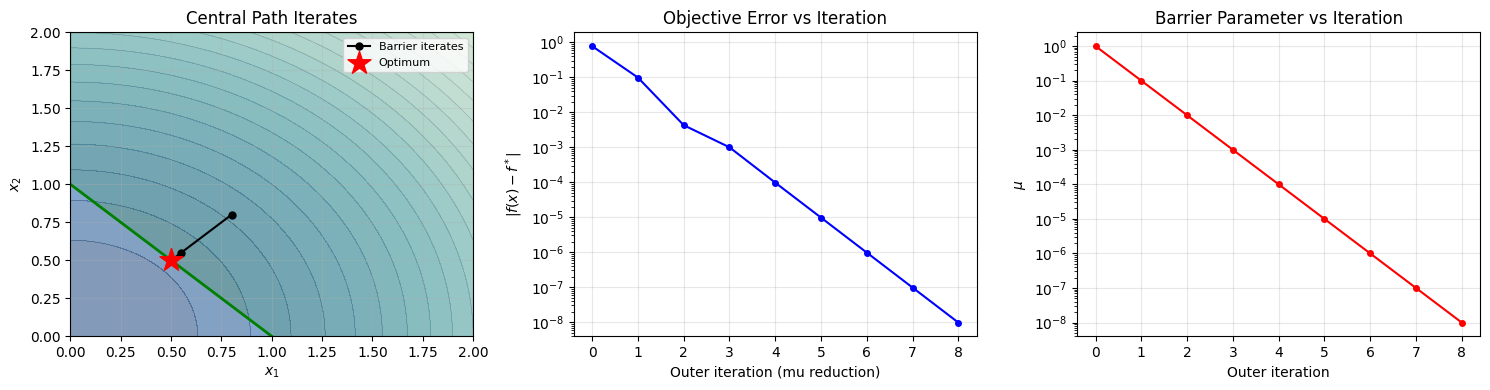

In [7]:
# Visualize convergence history
mus_hist    = [h[0] for h in hist]
xs_hist     = np.array([h[1] for h in hist])
fs_hist     = [h[2] for h in hist]
gnorms_hist = [h[3] for h in hist]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Central path on feasible region
ax = axes[0]
x1g = np.linspace(0, 2, 200)
x2g = np.linspace(0, 2, 200)
X1, X2 = np.meshgrid(x1g, x2g)
F = X1**2 + X2**2
ax.contourf(X1, X2, F, levels=20, cmap='Blues_r', alpha=0.5)
ax.contour(X1, X2, F, levels=20, colors='gray', linewidths=0.5, alpha=0.4)
x1f = np.linspace(0, 2, 200)
ax.fill_between(x1f, np.maximum(1 - x1f, 0), 2, alpha=0.15, color='green')
ax.plot(x1f, 1 - x1f, 'g-', lw=2)
ax.plot(xs_hist[:, 0], xs_hist[:, 1], 'k-o', ms=5, label='Barrier iterates')
ax.scatter([0.5], [0.5], marker='*', s=300, color='red', zorder=10, label='Optimum')
ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Central Path Iterates')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# f(x) vs outer iteration
ax = axes[1]
ax.semilogy(range(len(mus_hist)), [abs(f - 0.5) for f in [f_func(x) for x in xs_hist]],
            'b-o', ms=4)
ax.set_xlabel('Outer iteration (mu reduction)')
ax.set_ylabel('$|f(x) - f^*|$')
ax.set_title('Objective Error vs Iteration')
ax.grid(True, alpha=0.3)

# mu vs outer iteration
ax = axes[2]
ax.semilogy(range(len(mus_hist)), mus_hist, 'r-o', ms=4)
ax.set_xlabel('Outer iteration')
ax.set_ylabel('$\\mu$')
ax.set_title('Barrier Parameter vs Iteration')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('barrier_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Complementarity from the Barrier Stationarity Condition

This is a crucial insight. At the minimum of $\phi(x, \mu)$:
$$\frac{\partial \phi}{\partial x_i} = \frac{\partial f}{\partial x_i} - \frac{\mu}{x_i - x_{l,i}} + \frac{\mu}{x_{u,i} - x_i} = 0$$

Define **barrier multipliers**:
$$z_{l,i} = \frac{\mu}{x_i - x_{l,i}} > 0, \qquad z_{u,i} = \frac{\mu}{x_{u,i} - x_i} > 0$$

Then stationarity says: $\nabla f(x) - z_l + z_u = 0$ (exactly the KKT stationarity condition for bounds!).

And the **perturbed complementarity** conditions hold automatically:
$$z_{l,i} \cdot (x_i - x_{l,i}) = \mu, \qquad z_{u,i} \cdot (x_{u,i} - x_i) = \mu$$

As $\mu \to 0$: these converge to $z_{l,i}(x_i - x_{l,i}) = 0$ and $z_{u,i}(x_{u,i} - x_i) = 0$ — the exact KKT complementarity conditions!

In [8]:
# Demonstrate perturbed complementarity for the 2D example
print('Perturbed Complementarity: z * slack = mu')
print('='*55)
print()
print('Problem: min x1^2+x2^2  s.t.  x1+x2>=1, 0<=xi<=2')
print('True KKT: x1*=x2*=0.5, z_l*=[0,0] (bounds inactive)')
print('          lambda* = 1 (inequality constraint active)')
print()

mu_test_list = [1.0, 0.1, 0.01, 0.001, 1e-6]
g_ineq_bnd_funcs = [(g_ineq, jac_g)]

print(f'{'mu':>8}  {'x1':>8}  {'x2':>8}  {'z_l1*slack1':>13}  {'lambda*(-g)':>13}')
print('-'*60)

x = np.array([0.8, 0.8])
for mu_t in mu_test_list:
    # Newton solve for phi(x, mu_t)
    for _ in range(100):
        g = barrier_gradient(x, grad_f, g_ineq_bnd_funcs, x_l, x_u, mu_t)
        H = barrier_hessian(x, hess_f, g_ineq_bnd_funcs, x_l, x_u, mu_t)
        if np.linalg.norm(g) < 1e-12:
            break
        try:
            dx = np.linalg.solve(H, -g)
        except:
            break
        alpha = 1.0
        for _ in range(40):
            xn = x + alpha * dx
            if np.isfinite(barrier_objective(xn, f_func, g_ineq_bnd_funcs, x_l, x_u, mu_t)):
                break
            alpha *= 0.5
        x = x + alpha * dx

    z_l1 = mu_t / (x[0] - x_l[0])
    slack1 = x[0] - x_l[0]
    g_val = g_ineq(x)
    lam = mu_t / (-g_val)

    print(f'{mu_t:8.1e}  {x[0]:8.5f}  {x[1]:8.5f}  {z_l1*slack1:13.2e}  {lam*(-g_val):13.2e}')

print()
print('Both z_l*slack and lambda*(-g) converge to mu!')
print('As mu->0, these -> 0, recovering exact complementarity.')

Perturbed Complementarity: z * slack = mu

Problem: min x1^2+x2^2  s.t.  x1+x2>=1, 0<=xi<=2
True KKT: x1*=x2*=0.5, z_l*=[0,0] (bounds inactive)
          lambda* = 1 (inequality constraint active)

      mu        x1        x2    z_l1*slack1    lambda*(-g)
------------------------------------------------------------
 1.0e+00   0.50000   0.50000       1.00e+00       1.00e+00
 1.0e-01   0.50000   0.50000       1.00e-01       1.00e-01
 1.0e-02   0.50000   0.50000       1.00e-02       1.00e-02
 1.0e-03   0.50000   0.50000       1.00e-03       1.00e-03
 1.0e-06   0.50000   0.50000       1.00e-06       1.00e-06

Both z_l*slack and lambda*(-g) converge to mu!
As mu->0, these -> 0, recovering exact complementarity.


## 7. Connection to ripopt

The logarithmic barrier method is the **theoretical foundation** of ripopt.

**In `src/ipm.rs`:**
- The barrier parameter `mu` is initialized around 0.1 and decreases toward `1e-8`.
- `z_l` and `z_u` are the barrier multipliers for lower and upper bounds, maintained explicitly as variables.
- The perturbed complementarity `z_l * (x - x_l) = mu` and `z_u * (x_u - x) = mu` is enforced.

**In `src/convergence.rs`:**
- The convergence test checks `max(z_l * slack_l, z_u * slack_u) <= mu` (complementarity residual).
- `avg_compl` is the average of all complementarity products — when this is small, the solver is near the central path for the current `mu`.

**Key difference: Primal-Dual IPM vs. Pure Barrier**

Pure barrier method (this notebook): separate Newton solve for each $\mu$ value.

Primal-dual IPM (next notebook): simultaneously solve for $(x, z, y)$ together, treating them all as unknowns. This allows taking just one Newton step per $\mu$ reduction, or even updating $\mu$ adaptively — much more efficient in practice.

The barrier formulation shows **why** the primal-dual system has the structure it does: the $\Sigma$ diagonal in the KKT matrix comes directly from $\nabla^2 \phi = \nabla^2 f + \Sigma$.

In [9]:
# Summary: demonstrate how Sigma relates barrier to IPM KKT
print('Barrier Hessian = f Hessian + Sigma (barrier diagonal term)')
print()

x_ex = np.array([0.6, 0.7])
mu_ex = 0.05

H_f = hess_f(x_ex)
s_l = x_ex - x_l
s_u = x_u - x_ex
z_l = mu_ex / s_l
z_u = mu_ex / s_u
Sigma = np.diag(z_l / s_l + z_u / s_u)  # = mu*(S_l^{-2} + S_u^{-2})

print(f'x = {x_ex}, mu = {mu_ex}')
print(f'z_l = {z_l}  (barrier lower multipliers)')
print(f'z_u = {z_u}  (barrier upper multipliers)')
print(f'Sigma = diag({np.diag(Sigma)})  (adds positive definite contribution)')
print()
print('H_barrier = H_f + Sigma:')
print(H_f + Sigma)
print()
print('This Sigma appears in the (1,1) block of the IPM KKT system!')
print('It ensures the (1,1) block is positive definite, which is essential')
print('for the KKT system to have the correct inertia (notebook 8).')

Barrier Hessian = f Hessian + Sigma (barrier diagonal term)

x = [0.6 0.7], mu = 0.05
z_l = [0.083333 0.071429]  (barrier lower multipliers)
z_u = [0.035714 0.038462]  (barrier upper multipliers)
Sigma = diag([0.164399 0.131627])  (adds positive definite contribution)

H_barrier = H_f + Sigma:
[[2.164399 0.      ]
 [0.       2.131627]]

This Sigma appears in the (1,1) block of the IPM KKT system!
It ensures the (1,1) block is positive definite, which is essential
for the KKT system to have the correct inertia (notebook 8).


## Summary

| Concept | Formula | Role |
|---------|---------|------|
| Barrier function | $\phi(x,\mu) = f(x) - \mu\sum_i \log(x_i - x_{l,i})$ | Encodes bound constraints |
| Central path | $x^*(\mu) = \arg\min_x \phi(x,\mu)$ | Parametric interior solution |
| Barrier multiplier | $z_{l,i} = \mu/(x_i - x_{l,i})$ | Approximates KKT multiplier |
| Perturbed complementarity | $z_{l,i}(x_i - x_{l,i}) = \mu$ | Relaxed KKT condition |
| Barrier Hessian | $\nabla^2\phi = \nabla^2 f + \Sigma$ | Ensures positive (1,1) block |

**Next notebook:** We upgrade from barrier method (one inner solve per $\mu$) to the primal-dual IPM, which simultaneously updates $x$, $z$, and $y$ — taking Newton steps on the perturbed KKT system directly. This is what makes interior point methods fast in practice.